# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`
# `Занятие 08. Свёрточные архитектуры`
## `Занятие провел: Оганов Александр (@welmud)`
## `Материалы составил: Оганов Александр (@welmud)`
## `Материалы основаны на лекции Садртдинова Ильдуса Рустемовича`

### `Москва, Весенний семестр 2026`

Источники:
- [Лекция Садртдинова Ильдуса Рустемовича на курсе "Введение в глубокое обучение" факультета ФКН](https://github.com/isadrtdinov/intro-to-dl-hse/blob/1fd3f9bf82fc7aa8e0475210318423559f02f582/lecture-notes/notes-05-cnn.pdf)

- **LeNet**: [Yann LeCun et al., 1998](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf), примерно 84 тысячи цитирований
- **ImageNet**: [O.Russakovsky et al., 2015](https://arxiv.org/abs/1409.0575), примерно 49 тысяч цитирований
- **AlexNet**: [Krizhevsky et al., 2012](https://proceedings.neurips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf), примерно 150 тысяч цитирований
- **VGG**: [Simonyan and Zisserman, 2014](https://arxiv.org/abs/1409.1556), примерно 160 тысяч цитирований
- **GoogLeNet (a.k.a. Inception)**: [Szegedy et al., 2014](https://arxiv.org/abs/1409.4842), примерно 71 тысяча цитирований
- **ResNet**: [He et al., 2015](https://arxiv.org/abs/1512.03385), примерно 310 тысяч цитирований
- Ландшафт функции потерь при skip connections: [Hao Li et al., 2017](https://arxiv.org/abs/1712.09913), примерно 3 тысячи цитирований
- [Ландшафты функций потерь](https://losslandscape.com/videos/)
- Ансамблирование в skip connections: [Veit et al., 2016](https://arxiv.org/abs/1605.06431), примерно 1500 цитирований
- **DenseNet**: [Huang et al., 2016](https://arxiv.org/abs/1608.06993), примерно 60 тысяч цитирований
- **MobileNet**: [Howard et al., 2017](https://arxiv.org/abs/1704.04861), примерно 37 тысяч цитирований
- **NASNet**:  [Zoph et al., 2017](https://arxiv.org/abs/1707.07012), примерно 9 тысяч цитирований
- **EfficientNet**: [Tan and Le, 2019](https://arxiv.org/abs/1905.11946), примерно 35 тысяч цитирований
- **ConvNet**: [Liu et al., 2022](https://arxiv.org/abs/2201.03545), примерно 12 тысяч цитирований

Это занятие будет посвящено развитию сверточных архитектур. Мы проследим, как проверялись различные гипотезы и как менялась область с течением времени, опираясь на ключевые статьи. Для каждой работы мы разберем, какую проблему она решала, обсудим роль бенчмарков, а также идеи, которые впоследствии перешли в другие области, и способы их интерпретации. Мы также затроним одну из самых важных идей для глубинного обучения &ndash; перенос знаний (transfer learning). Количество цитирований указано для того, чтобы дать представление о масштабе области и вовлеченности научного сообщества, а **не** для прямого сравнения статей друг с другом.


---

## Свёрточные архитектуры

Разговаривать об архитектурах можно долго, много и сложно, но наша цель чуть другая. Мы не собираемся разобраться в каждой модели из зоопарка (действительно есть [model zoo](https://modelzoo.co/)), мы хотим понять какие проблемы стояли и какие идеи позволили их решить или чуть схитрить.

Мы часто будем обращаться к **основному принципу** глубокого обучения: "чем больше слоев, тем лучше" или иными словами **stack more layers**.

### Самая простая схема свёрточной сети для классификации

На прошлом занятии мы описали самую простую свёрточную архитектуру.

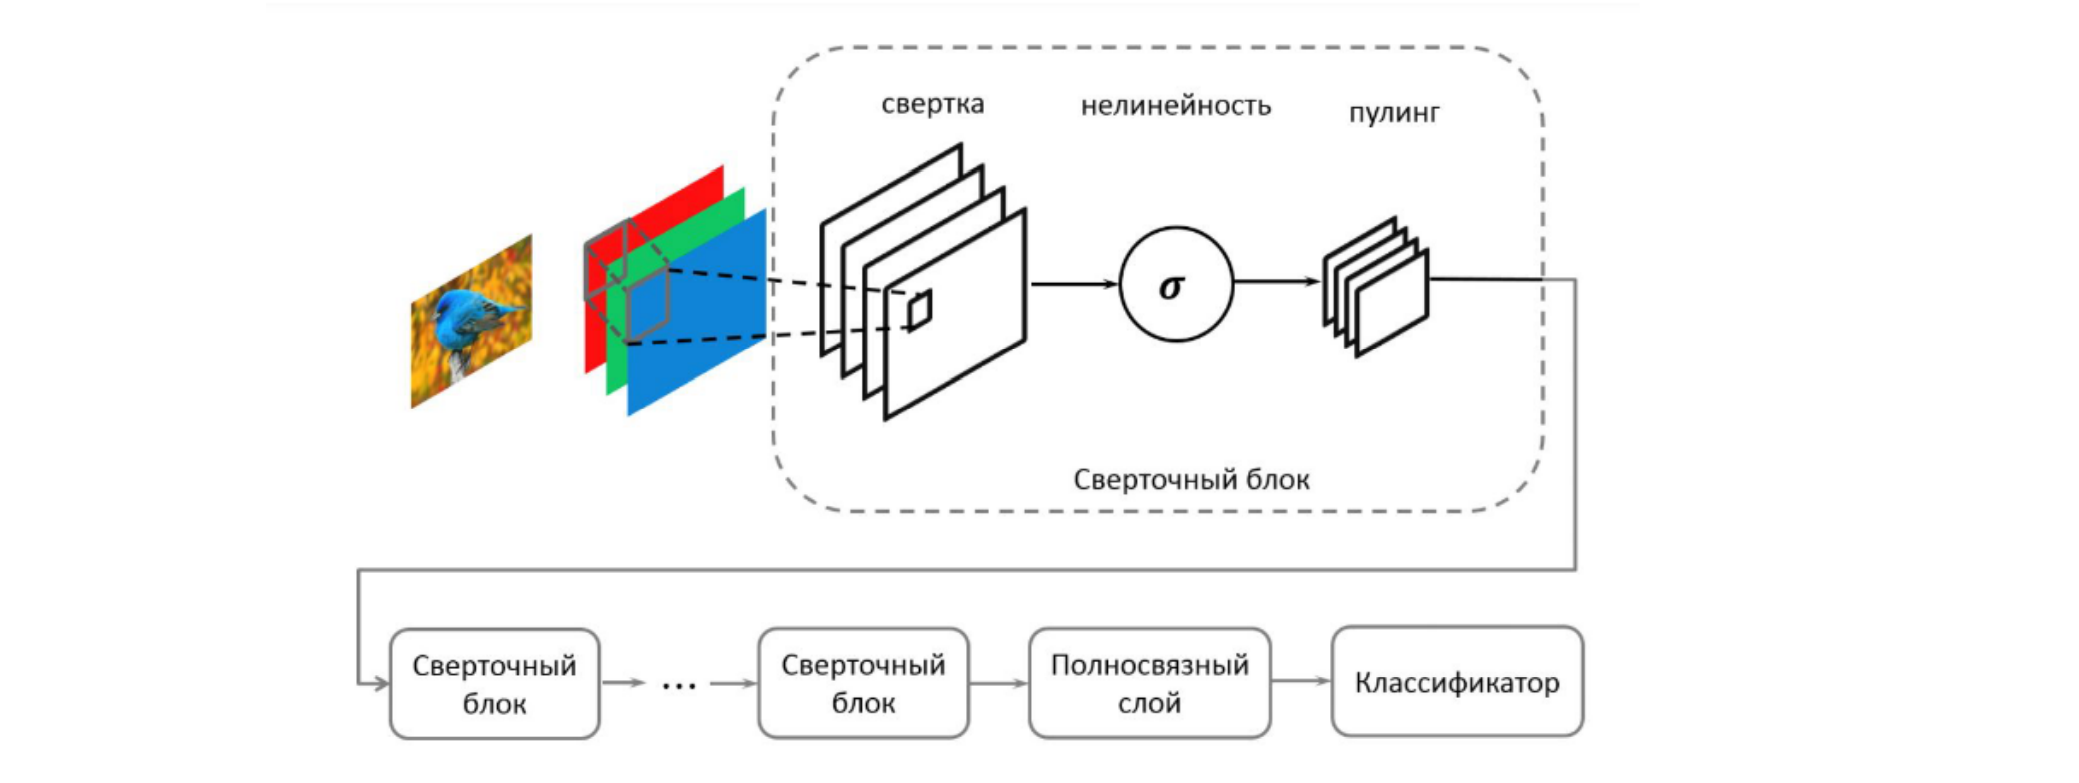

[Источник](http://www.machinelearning.ru/wiki/images/7/71/Voron-ML-DeepLearning-slides.pdf)

### `LeNet (1998)`  

[Yann LeCun et al., 1998](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf), примерно 84 тысячи цитирований

Первая свёрточная появилась достаточно давно и чем-то соответствовала схеме предложенной выше.

- Свёрточные слои и слои Subsampling (pooling) 
- В качестве функций активации взяты `Sigmoid`
- В качестве головы полносвязные слои
- Работает для изображений фиксированного размера

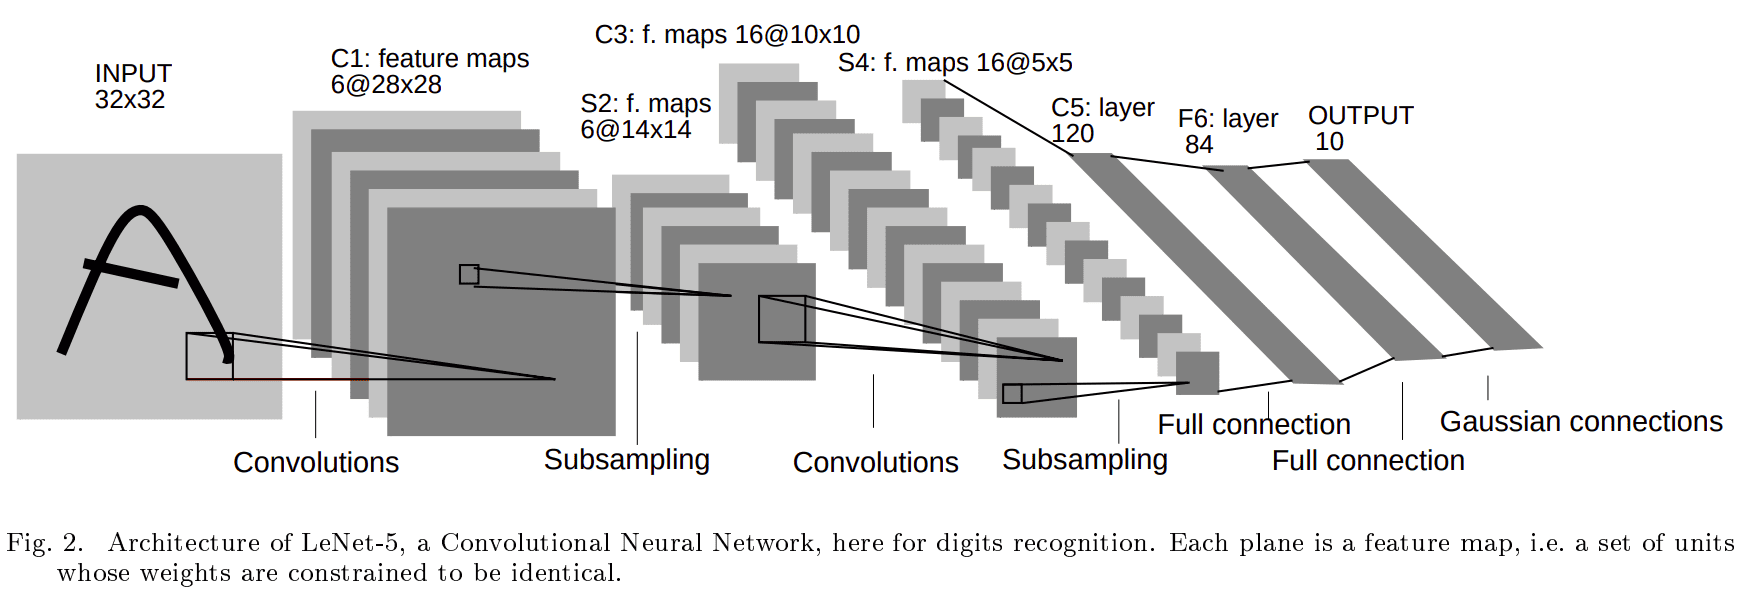

<font color='orange'>**Вопрос:**</font> Какие проблемы вы видите?

#### Ответ:

Ответов может быть много, например:
- На входе изображения размера 32
- Будут затухать градиенты от Sigmoid
- Сразу происходит pooling, мы можем потерять информацию

Однако важно учитывать, что мы говорим про 1998 год. Кроме того, в статье решалась не просто задача распознавания цифр или букв по отдельности, а распознавание последовательности рукописных символов с различными эвристиками. 

Выше мы предложили архитектуру, вроде бы, она даже выглядит разумно, теперь рассмотрели архитектуру `LeNet`, как нам понять, что лучше? Пусть в соседней лаборатории предложили новую архитектуру, как понять, насколько она хорошая?


**Проблема:** Мы не умеем сравнивать архитектуры между собой, необходима некая единая сложная задача с понятной метрикой качества, необходим **benchmark**. Сегодня мы будем говорить про область классификации изображений, однако, вопрос хороших бенчмарков во многих областях всё ещё не решён.

### ImageNet

В 2012 году появился `ImageNet`, датасет, на котором каждый мог проверить модель. Подробнее описано в статье создателей [O.Russakovsky et al., 2015](https://arxiv.org/abs/1409.0575), примерно 49 тысяч цитирований. 

Здесь и далее мы будем приводить число цитат **не с целью оценки качества статьи** (так как нельзя мерить научную ценность только по количеству цитат), а **с целью демонстрации, того как много людей развивало и вложили свои труды в эту область**.


**ImageNet статистика**
- 1000 классов
- ILSVRC-2012: 1.2M изображений (~150Gb)
- Сейчас уже более 14M изображений для решения разных задач: детекция, локализация, детекция по видео


Благодаря удобной инфраструктуре, открытому доступу получилось создать соревнование, в котором участвовали многие исследователи в области обработки изображений, тем самым оценивая свои идеи на едином бенчмарке. Возможно, именно благодаря `ImageNet` людям удалось так быстро решить **прикладные и фундаментальные проблемы DL**.

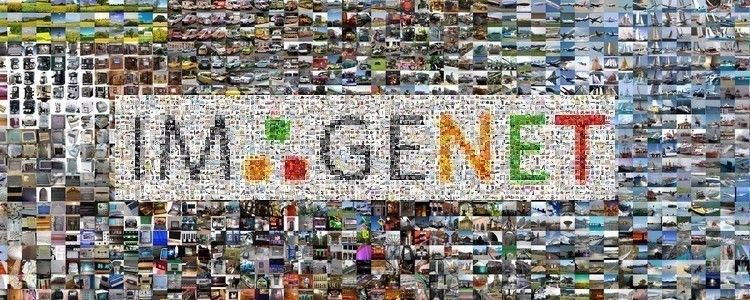

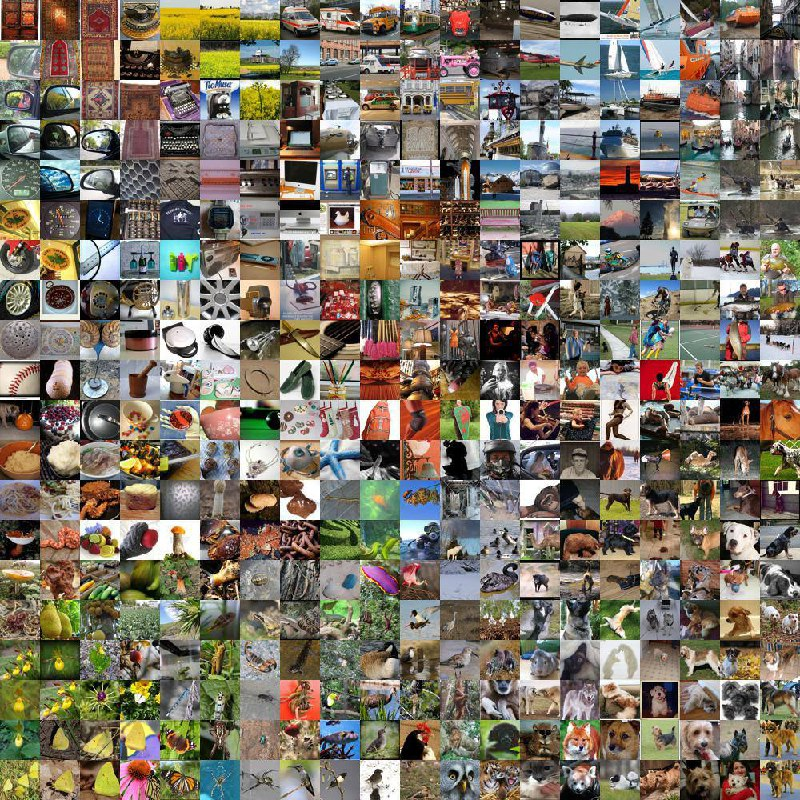

### Результаты

Ниже представлены результаты, которые получались в разные годы, нам важно отметить **появление глубокого обучения** и почему резко **число слоев** увеличилось. Именно об этом мы будем говорить дальше.

Важно, что оценка человеческой точности не совсем честная, так как время для определения было ограничено и классифицировать изображения редких животных бывает трудно. Не стоит забывать, что выбрать подходящий класс из возможных 1000 бывает трудно, как минимум, держать в памяти все возможные классы. Подробнее можно прочитать в оригинальной статье [O.Russakovsky et al., 2015](https://arxiv.org/abs/1409.0575).

Крайне интересный блог про анализ ошибок доступен по [ссылке](https://karpathy.github.io/2014/09/02/what-i-learned-from-competing-against-a-convnet-on-imagenet/), автор Андрей Карпатый.

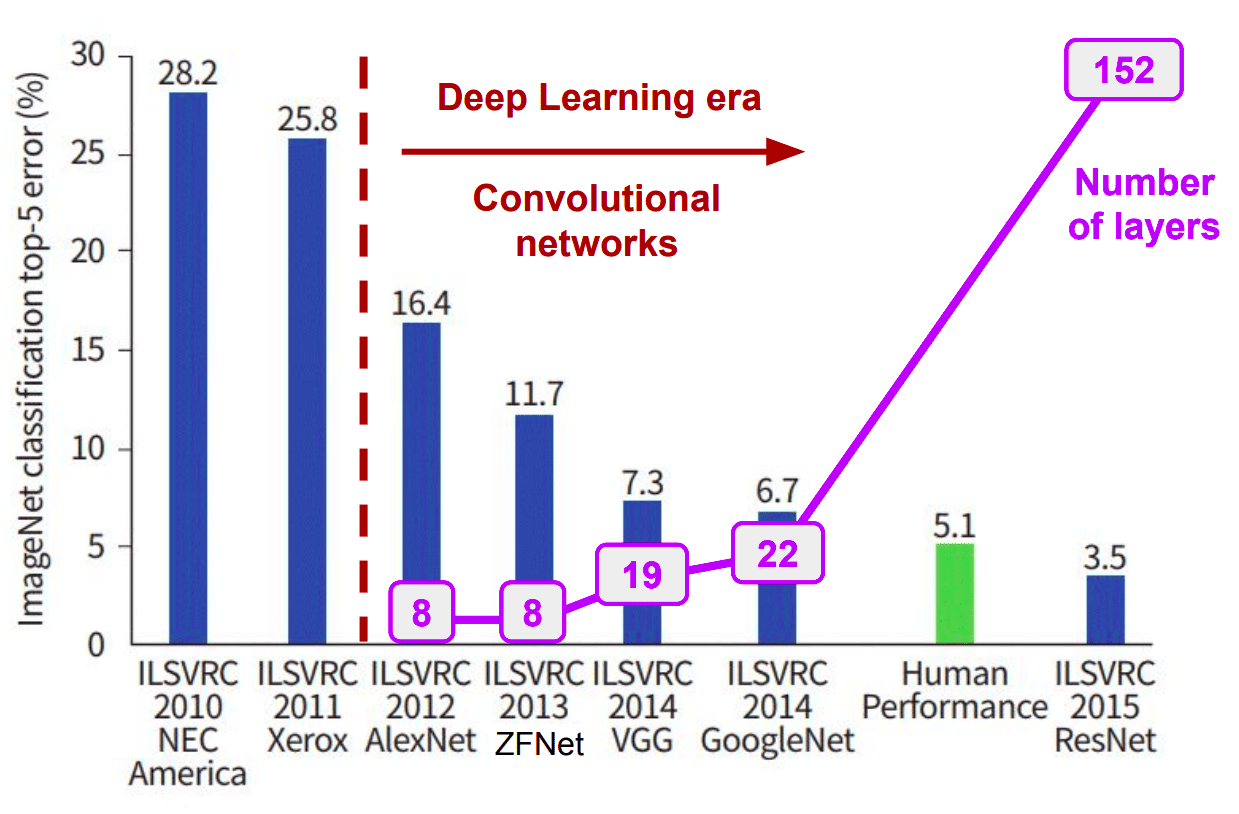

[Источник](https://github.com/isadrtdinov/intro-to-dl-hse/blob/1fd3f9bf82fc7aa8e0475210318423559f02f582/lecture-notes/notes-05-cnn.pdf)

### AlexNet (2012)

[Krizhevsky et al., 2012](https://proceedings.neurips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf), примерно 150 тысяч цитирований.

Впервые в истории DL попробовали обучить настолько большую сеть, которая даже не влезала на одну GPU, до этого люди сторонились огромных сетей и большого числа параметров.

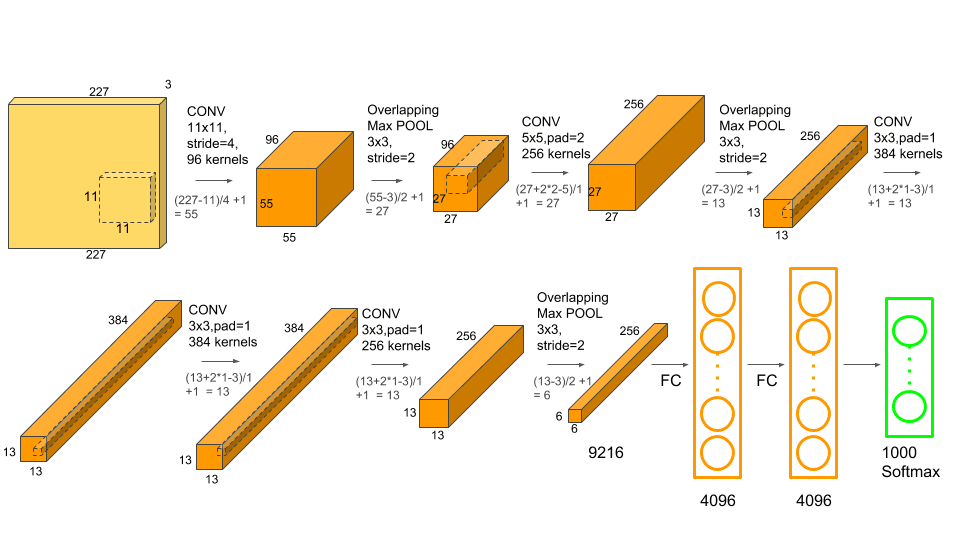

В начале люди старались учить "глубокие" нейросети, но резко столкнулись с проблемой затухания градиентов, даже при правильных функциях активации. Кроме того, приходилось все изображения приводить к одному размеру, так как полносвязный слой имеет фиксированную размерность входа.

Большая часть вычислительных мощностей тратилась на свёрточные блоки, при этом большинство параметров содержалось в линейных слоях.

- Max pooling, в качестве функций активации ReLU
- Dropout и Аугментация изображений для уменьшения переобучения
- 5-6 дней на 2 NVIDIA GTX 580 3GB
- Работает для изображений фиксированного размера


|         | Top-1 Accuracy | Top-5 Accuracy | Num params |
|---------|----------------|----------------|------------|
| AlexNet | 56.522         | 79.066         | 61M        |

*Метрики здесь и далее взяты из реализаций [torchvision](https://pytorch.org/vision/0.20/models.html)*

*P.S. PyTorch появился в 2016 году, а TensorFlow в 2015. Открытый исходный код появился только спустя 5 лет, его можно найти в этом [GitHub](https://github.com/computerhistory/AlexNet-Source-Code).*

### VGG (2014)

[Simonyan and Zisserman, 2014](https://arxiv.org/abs/1409.1556), примерно 160 тысяч цитирований.

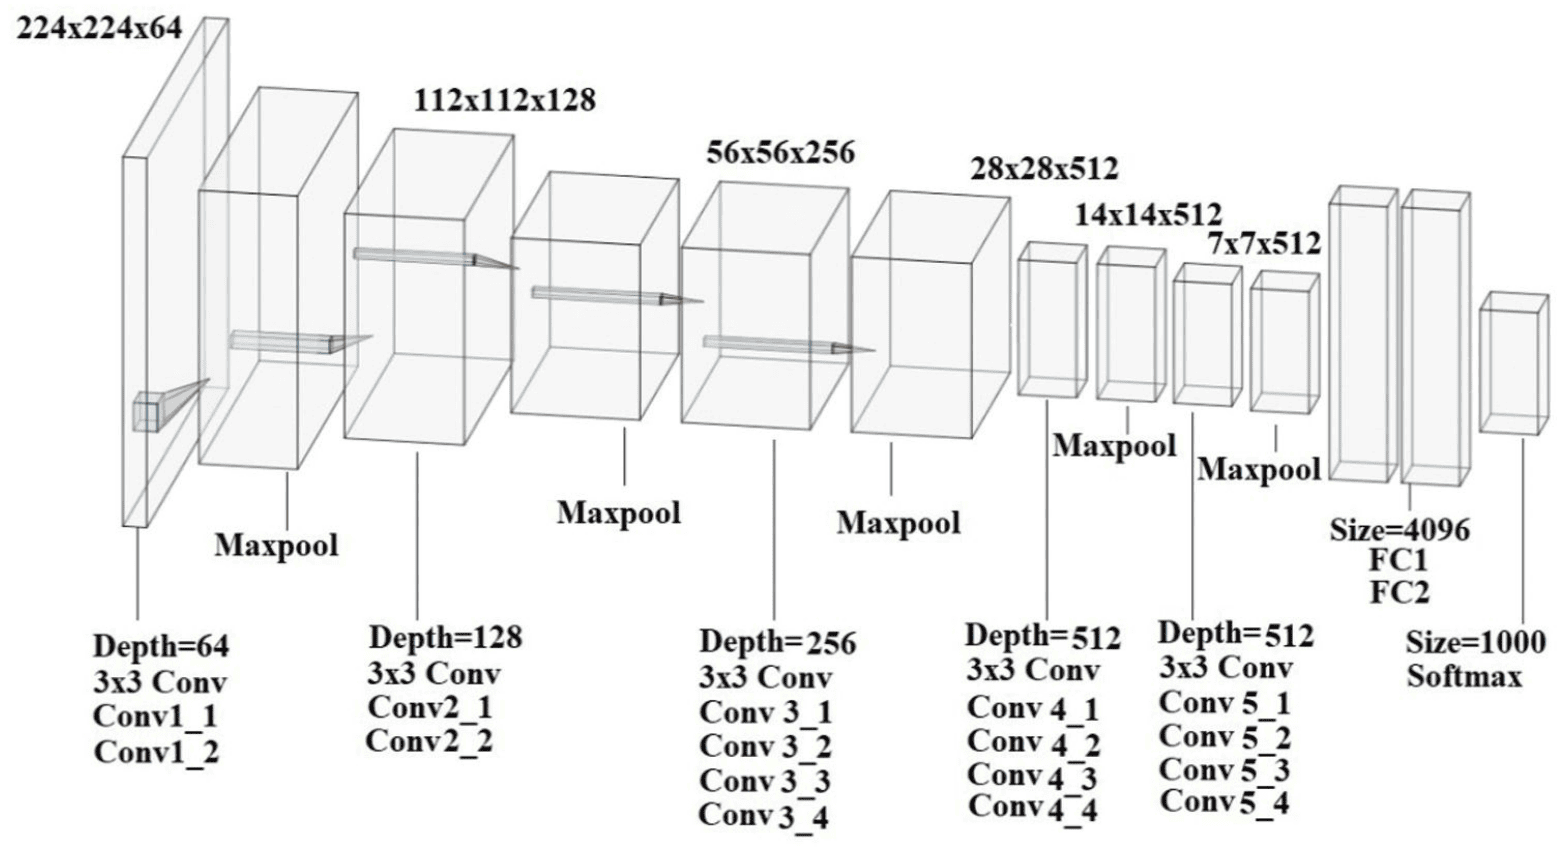

При обучении нейросети с глубиной 8 уже начинались проблемы, а обучить 19 слоев крайне трудно. При этом все в области понимали, что чем больше слоев, тем будет выше качество. В работе `VGG` предложили обучать не `end-to-end`, то есть не обучать всю нейросеть сразу. 

Например, мы можем обучить сначала первые 5 слоев, потом следующие и так далее. При этом на первой стадии мы используем 5 слоев, а потом добавляем на них полносвязанную голову.

<font color='orange'>**Вопрос:**</font> Какие проблемы вы видите в этом подходе?

#### Ответ:

Признаки, которые выучила модель на первой фазе, могут не подходить для второй, однако они почти не будут меняться из-за затухающих градиентов.

Кроме того, разные этапы обучения влекут разные гиперпараметры, что усложняет обучение и настройку модели.

В модели `VGG` стандартизировали все свёртки (все они с ядром размера 3), благодаря чему большая часть параметров хранится в свёрточных слоях, в отличие от `AlexNet`. Ядра с размером 3 требуют мало параметров, извлекают локальные признаки. Например, для достижения **receptive field** размера 5, мы можем взять 2 свёртки размера 3 (то есть 18 параметров) или одну свёртку размера 5 (25 параметров). В случае **receptive field** размера 11 эффективность оказывается еще заметнее.

- Visual Geometry Group (University of Oxford)
- Более глубокие сети: версии на 16 и 19 слоев
- Используются свёртки с ядром размера 3, привело к более эффективным вычислениям
- Проблема затухания градиентов привела к не end-to-end обучению
- Обучения стадиями
- 2-3 недели на 4 NVIDIA Titan Black GPU
- Работает для изображений фиксированного размера

|        | Top-1 Accuracy | Top-5 Accuracy | Num params |
|--------|----------------|----------------|------------|
| VGG-19 | 72.376         | 90.876         | 143.7M     |



*P.S. Первый автор выпускник ВМК, [подробнее тут](https://cs.msu.ru/news/3012).*

### GoogLeNet (a.k.a Inception, 2014)

[Szegedy et al., 2014](https://arxiv.org/abs/1409.4842), примерно 71 тысяча цитирований.

Впервые была использована идея применения разных слоев к одному входу, в частности применение разных свёрток параллельно к одной `feature map`.

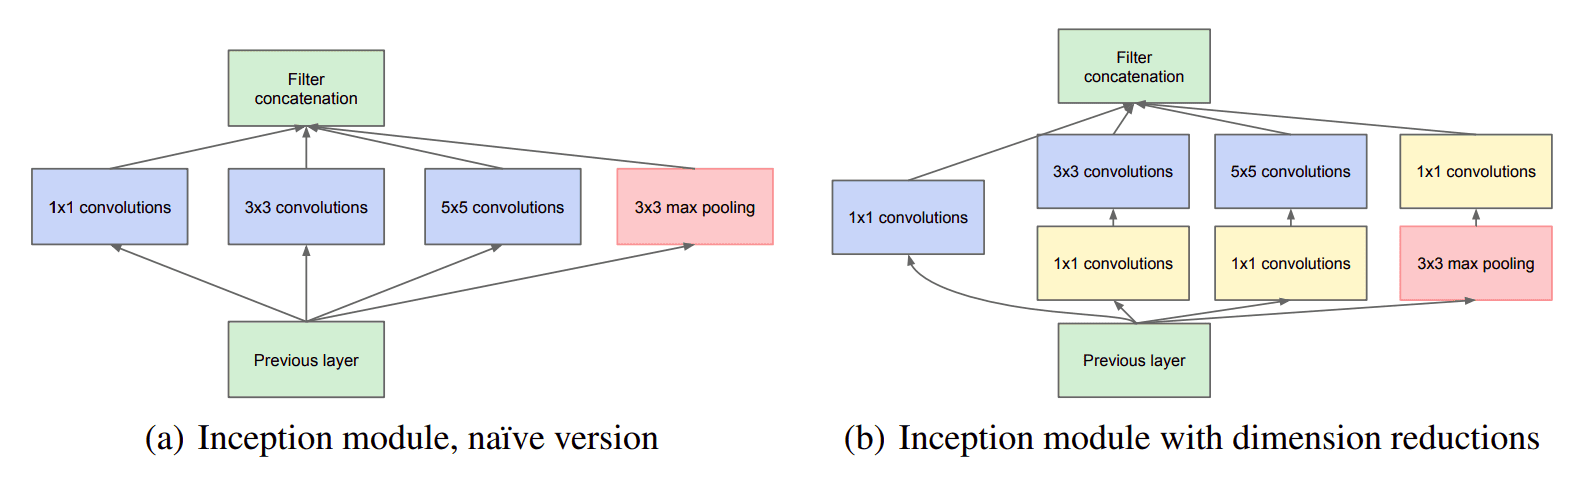

<font color='orange'>**Вопрос**</font> Какая интуиция стоит за параллельным использованием свёрток к одному изображению?

#### Ответ:

Возможно, мы хотим извлечь из изображения как глобальные, так и локальные признаки, тогда нам нужно пройтись одновременно как свёрткой с маленьким размером ядра, так и с более большим. В примере выше для глобальных свойств мы используем свёртки с ядром 5 и слои пуллинга.

С целью увеличения эффективности и уменьшения параметров используются свёртки **с ядром размера 1**, так как благодаря им получается уменьшить число каналов на вход свёрткам размера 3 и 5 (уменьшить число параметров в них).

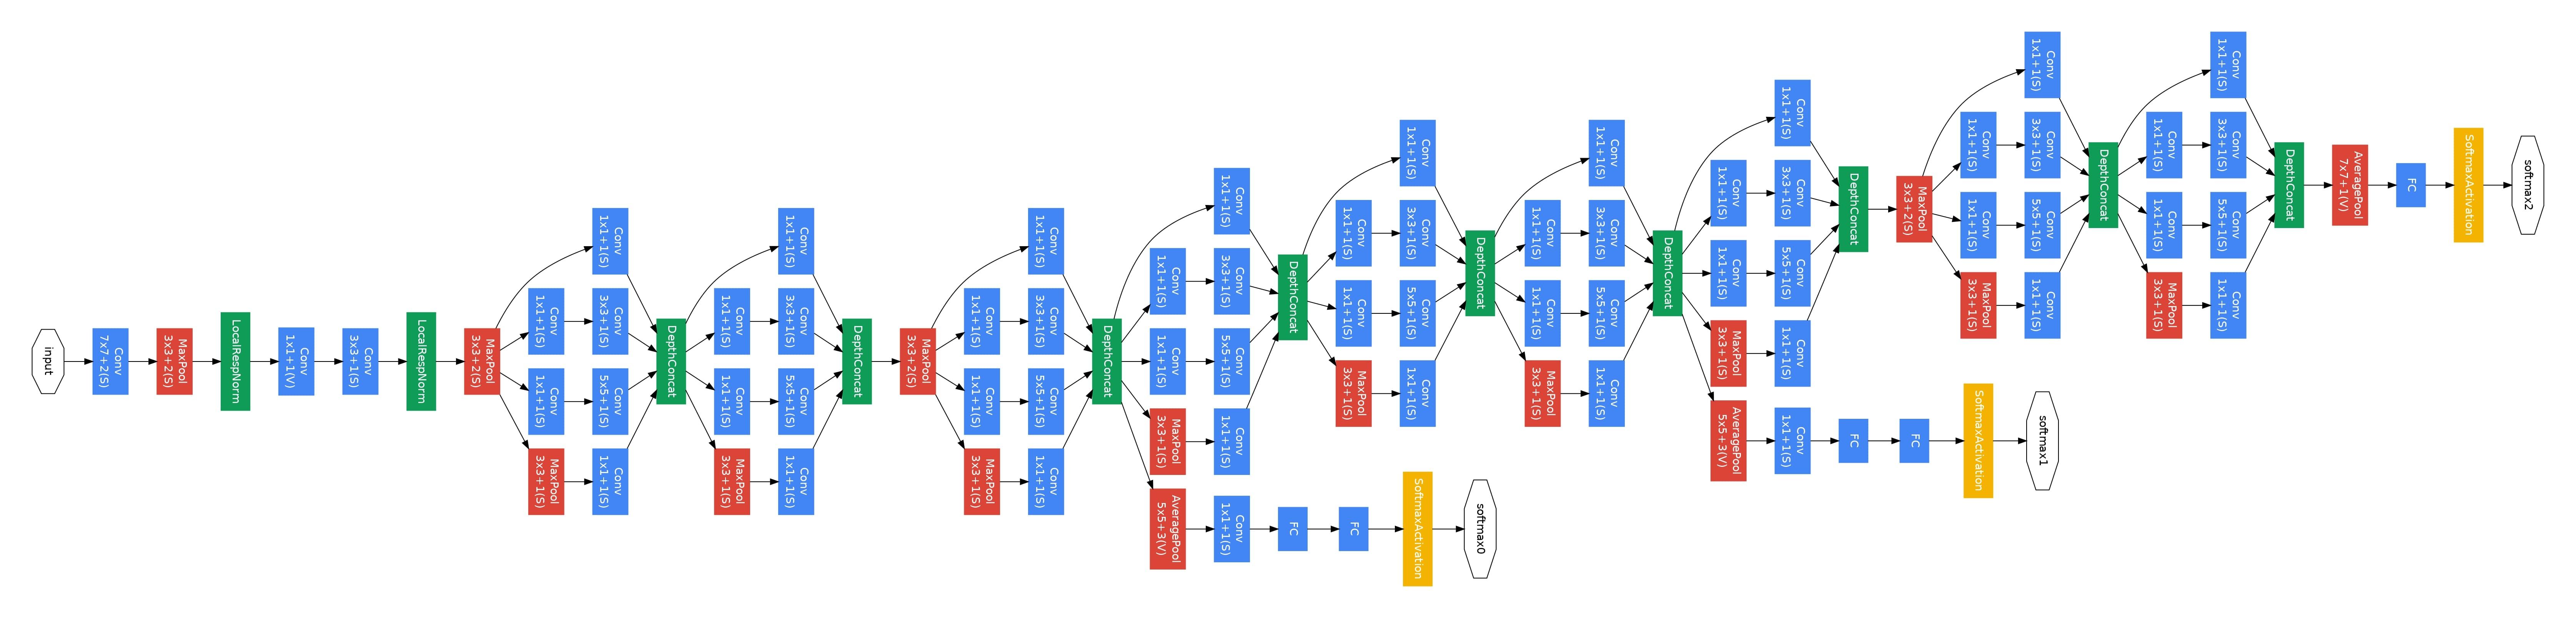

- Параллельные вычислительные блоки (архитектура не последовательная)
- Использование свёрток с разными ядром для повышения эффективности
- Не end-to-end обучение, использование вспомогательных классификаторов
- Работает для изображений фиксированного размера

|           | Top-1 Accuracy | Top-5 Accuracy | Num params |
|-----------|----------------|----------------|------------|
| GoogLeNet | 69.778         | 89.530         | 6.6M       |

### Residual (skip) connections (2015)

[He et al., 2015](https://arxiv.org/abs/1512.03385), примерно 310 тысяч цитирований (за 2025 год число цитирований увеличилось примерно на 50 тысяч). 

Все подходы выше старались увеличить число слоев и по-разному решали проблему затухания градиентов, чаще всего мы отказывались от end-to-end обучения. В этом случае процесс обучения становился сильно сложнее.

В 2015 году появилась идея, которая поменяла подход к построению архитектур не только в компьютерном зрении, но и в других областях. Ниже представлена схема и **изначальная мотивация** к использованию `skip connections`, а именно решение проблемы затухания градиентов.

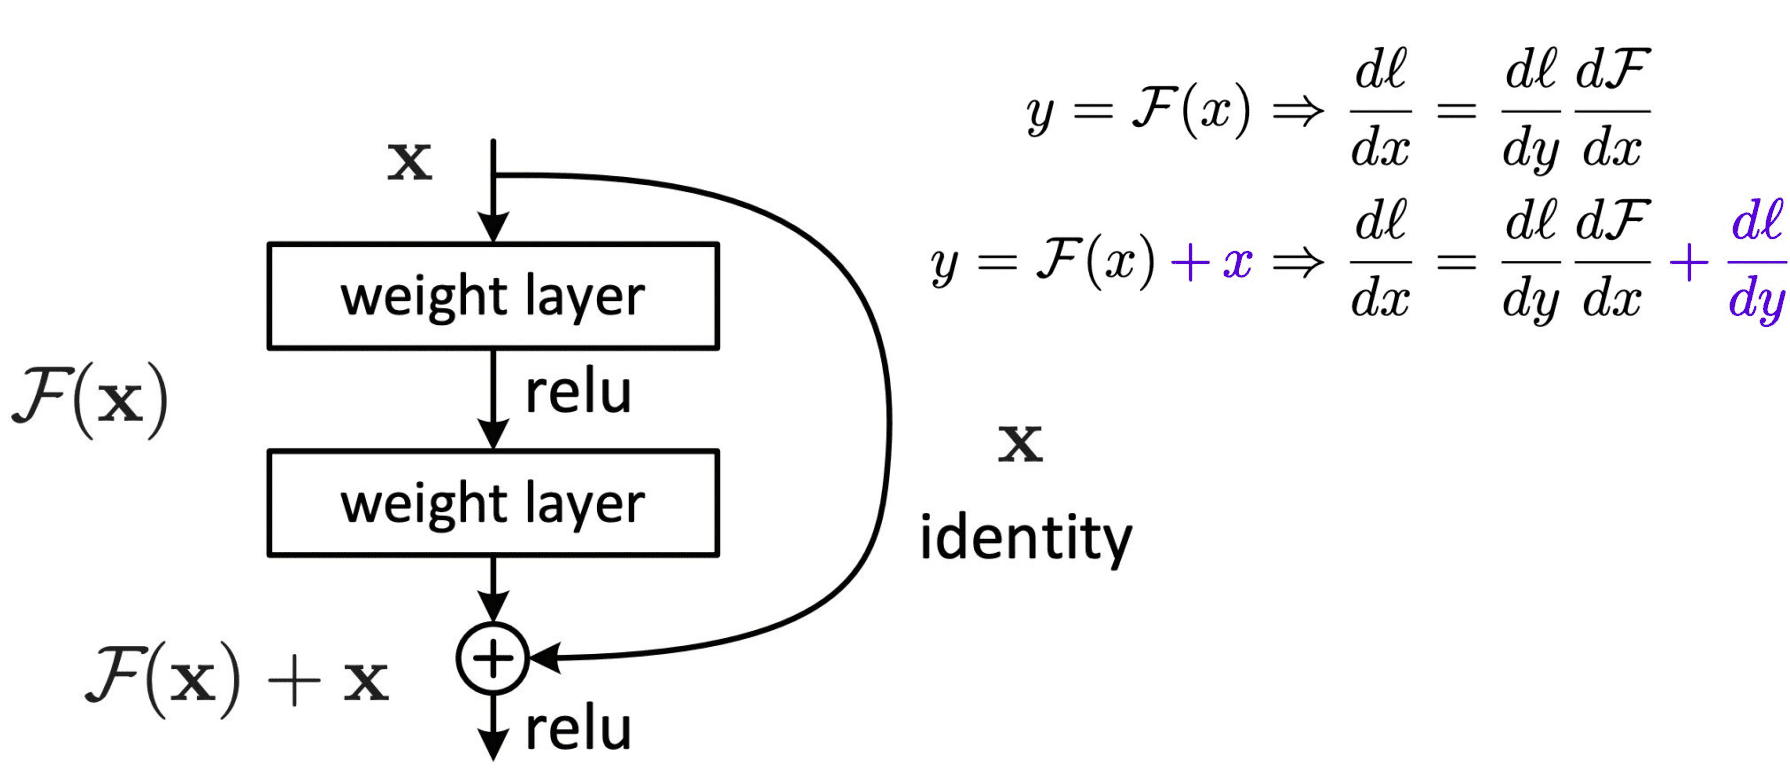

Ниже показан пример `skip connections` в блоке свёрточной сети.

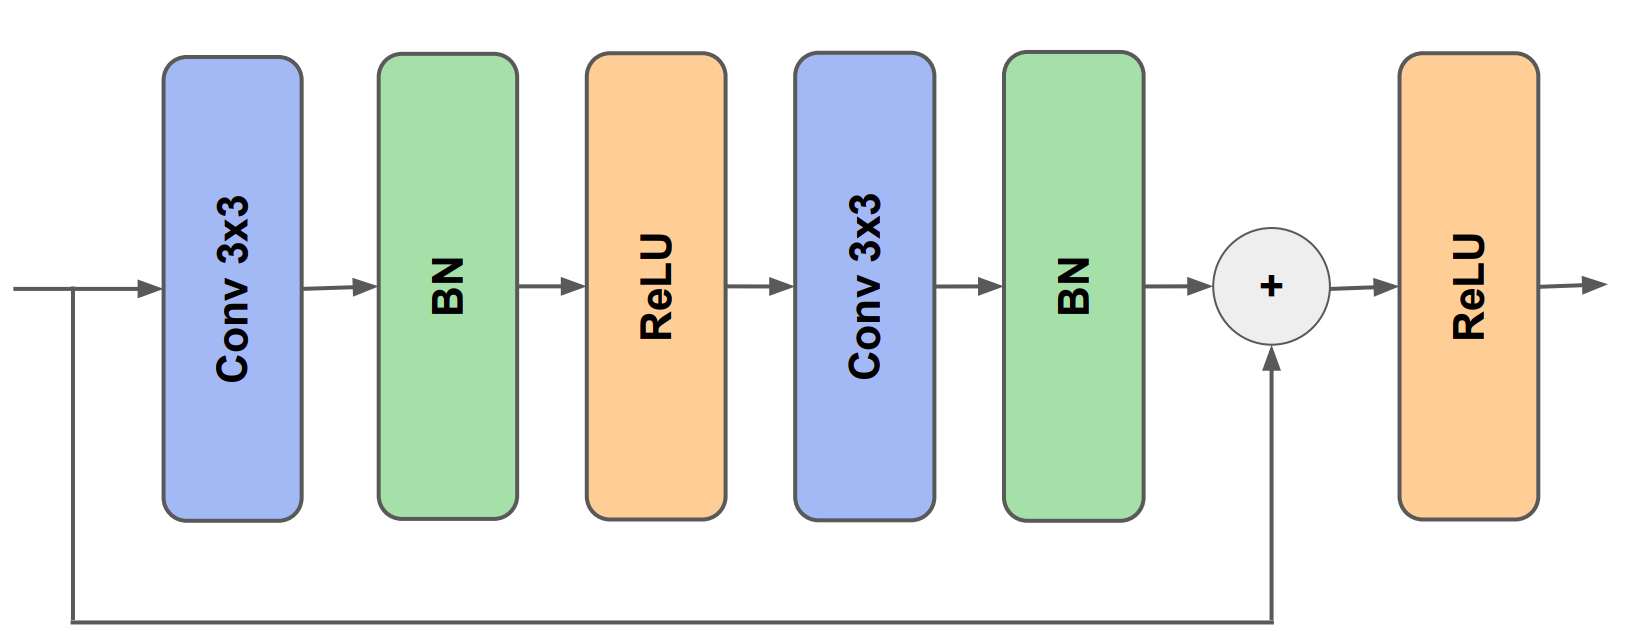

### ResNet (2015)

[He et al., 2015](https://arxiv.org/abs/1512.03385), примерно 310 тысяч цитирований (за 2025 год число цитирований увеличилось примерно на 50 тысяч). 

Поход с использованием  `skip connections` позволил обучать нейросети со **152 слоями**.

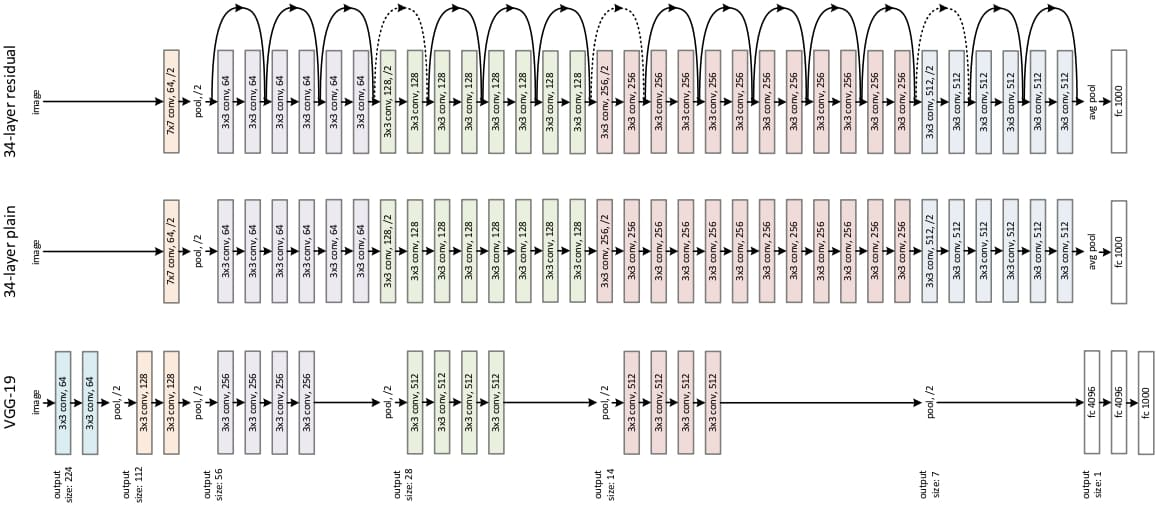

- **Residual connections** помогает течь градиентам лучше => можно брать сильно больше слоев!!! **stack MUCH MORE layers**
- Использование **batch normalization** для более стабильного обучения
- Вместо **pooling** слоев в блоках использовать свёртки с **stride=kernel_size** (как обсуждали ранее)
- **Global average pooling** то есть усреднение по размерности изображения ($H$ и $W$) на последнем слое, на выходе получаем вектор размерности равным числу каналов => обработка изображений любых размеров

**Важно:** использование **batch normalization** тоже упрощает обучение более глубоких слоев, например, если добавить батч нормализацию к `VGG`можно обучать `end-to-end`.

|            | Top-1 Accuracy | Top-5 Accuracy | Num params |
|------------|----------------|----------------|------------|
| ResNet-152 | 78.312         | 94.046         | 60.2M      |

<font color='orange'>**Вопрос:**</font> Почему Global average pooling работает? Какая интуиция может быть?

#### Ответ:

Мы говорили, что обычно, каждый канал извлекает свои признаки.

Рассмотрим пример где у нас 2 канала, например, горизонтальные линии на канале 1, а вертикальные на канале 2. Значит усреднее по размерности изображения даст вектор размерности 2. Первая компонента хранит информацию о среднем числе горизонтальных линий, а вторая о вертикальных.

Если признаки достаточно сложные (а мы используем много слоев, значит они сложные), то мы сможем классифицировать изображения зная средние признаки по изображению.

### Почему skip connections работают? (еще одно объяснение)

[Hao Li et al., 2017](https://arxiv.org/abs/1712.09913), примерно 3 тысячи цитирований. 

Существуют отдельные направления исследования ландшафта функции потерь нейронной сети (зависимость ошибки от параметров модели). В работе [Hao Li et al., 2017](https://arxiv.org/abs/1712.09913) изобразили ландшафт функции потерь в архитектуре с `skip connections` и без них.

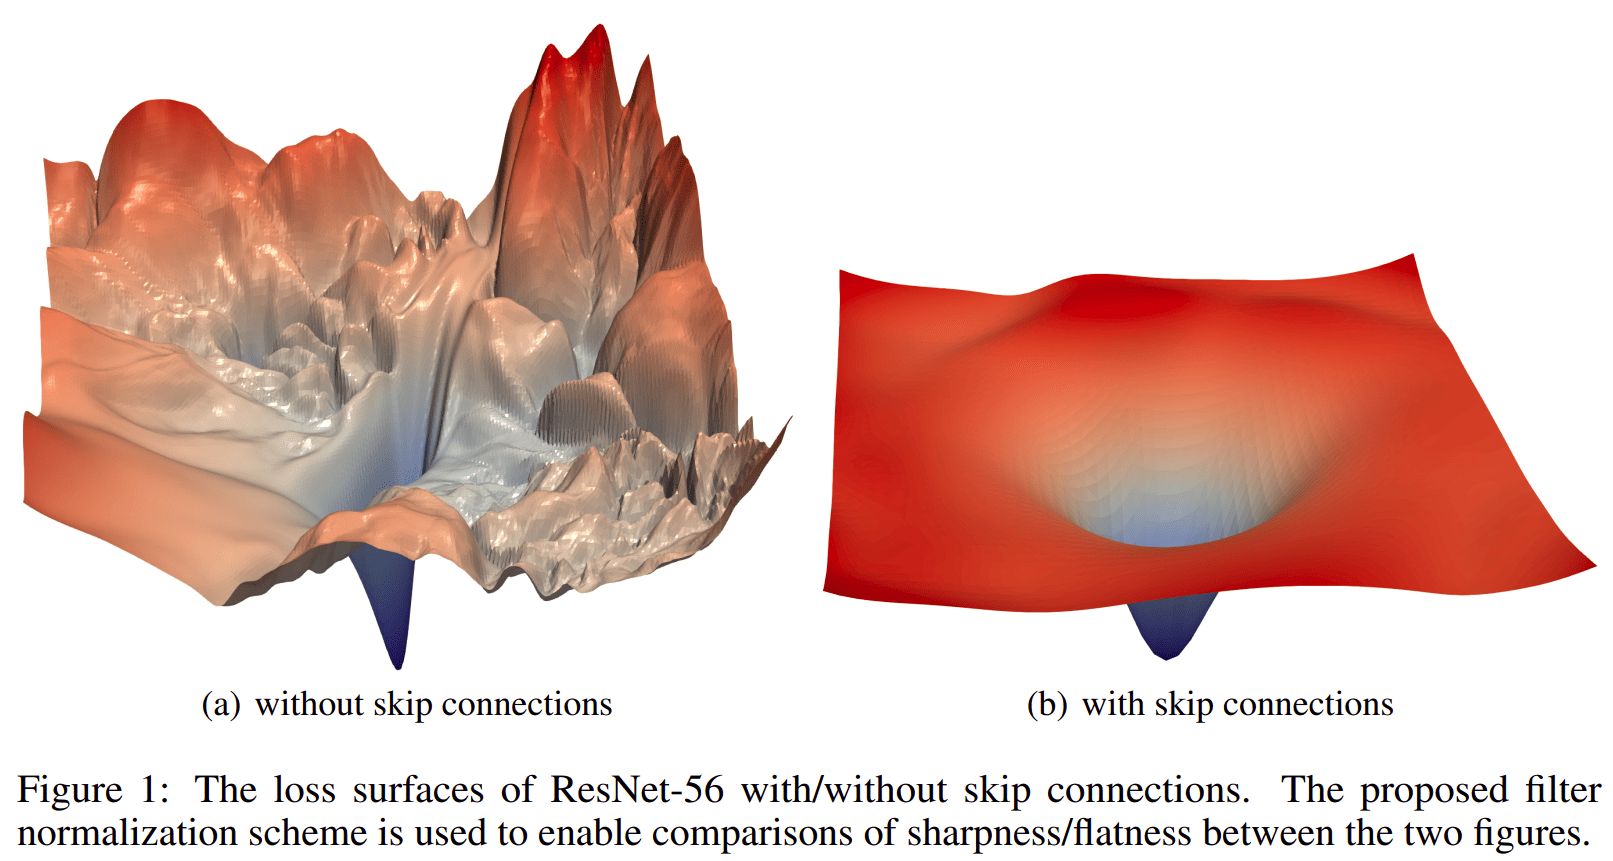

Область исследование ланшафтов функций потерь обычно называют **loss landscape**. В области есть много интересных и важных работ и разнообразных визуализаций ([пример](https://losslandscape.com/videos/)).

### Почему skip connections работают? (и ещё одно объяснение)


[Veit et al., 2016](https://arxiv.org/abs/1605.06431), примерно 1500 цитирований.

Можно посмотреть на нейросети со skip connections как некоторый подход к ансамблированию [Veit et al., 2016](https://arxiv.org/abs/1605.06431). Если расписать граф вычислений чуть аккуратней, то можно получить следующую картину:

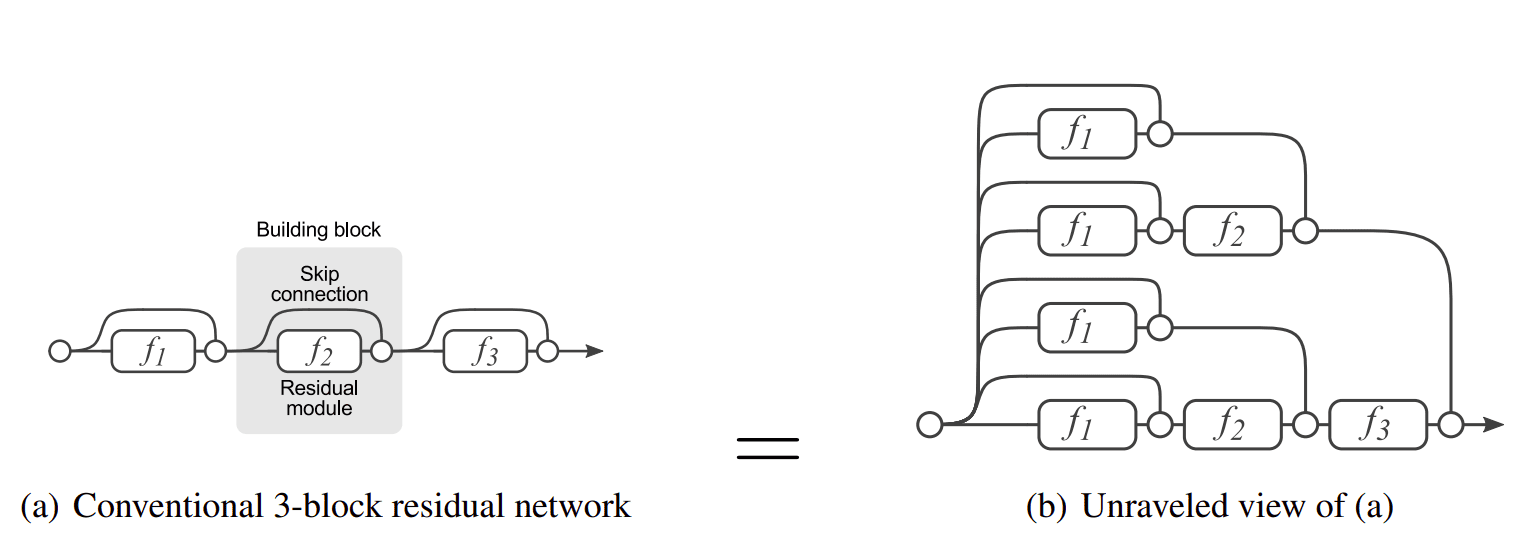

Если мы считаем, что вход равен $y_0$, тогда выход будет равен

$$
\begin{align*}
y_3 &= y_2 + f_3(y_2) \\
   &= [y_1 + f_2(y_1)] + f_3(y_1 + f_2(y_1)) =\\
   &= [y_0 + f_1(y_0)] + f_2(y_0 + f_1(y_0)) + f_3(y_0 + f_1(y_0) + f_2(y_0 + f1(y_0))).
\end{align*}
$$

Такая запись чем-то напоминает градиентный бустинг, а по интуиции из машинного обучения мы знаем, что ансимблирования это хороший способ поднять качество.

### Результаты

|            | Top-1 Accuracy | Top-5 Accuracy | Num params |
|------------|----------------|----------------|------------|
| AlexNet    | 56.522         | 79.066         | 61M        |
| VGG-19     | 72.376         | 90.876         | 143.7M     |
| GoogLeNet  | 69.778         | 89.530         | **6.6M**   |
| ResNet-152 | **78.312**     | **94.046**     | 60.2M      |

### Что было дальше?

С появлением `ResNet-152` люди научились решать задачу классификации изображений точнее человека*. Следующая цель была заставить мощные классификаторы работать на телефонах и без мощных GPU. Для этого попробовали много чего, но мы поговорим об этом кратко, так как у нас другие цели. Все желающие могут посмотреть подробнее в [источнике](https://github.com/isadrtdinov/intro-to-dl-hse/blob/1fd3f9bf82fc7aa8e0475210318423559f02f582/lecture-notes/notes-05-cnn.pdf).

Зоопарк моделей:

- DenseNet [Huang et al., 2016](https://arxiv.org/abs/1608.06993): добавили **residual connections** между любыми двумя слоями
- MobileNet [Howard et al., 2017](https://arxiv.org/abs/1704.04861): подобрали определенные свёрточные блоки для эффективной реализации (использование свёрток с ядром размера 1)
- NASNet  [Zoph et al., 2017](https://arxiv.org/abs/1707.07012): обучили умный перебор (Neural Architecture Search) всех возможных архитектур из заранее заданных блоков (об этом подробнее в следующем семестре)
- EfficientNet [Tan and Le, 2019](https://arxiv.org/abs/1905.11946): использовали NAS на блоках на специальных блоках, mobile NAS


Результаты 2019 года представлены на графике ниже, важно отметить, что рассматриваемые модели это именно свёрточные архитектуры.


*в специальных условиях, с некоторыми ограничениями по времени. Об этом было выше.

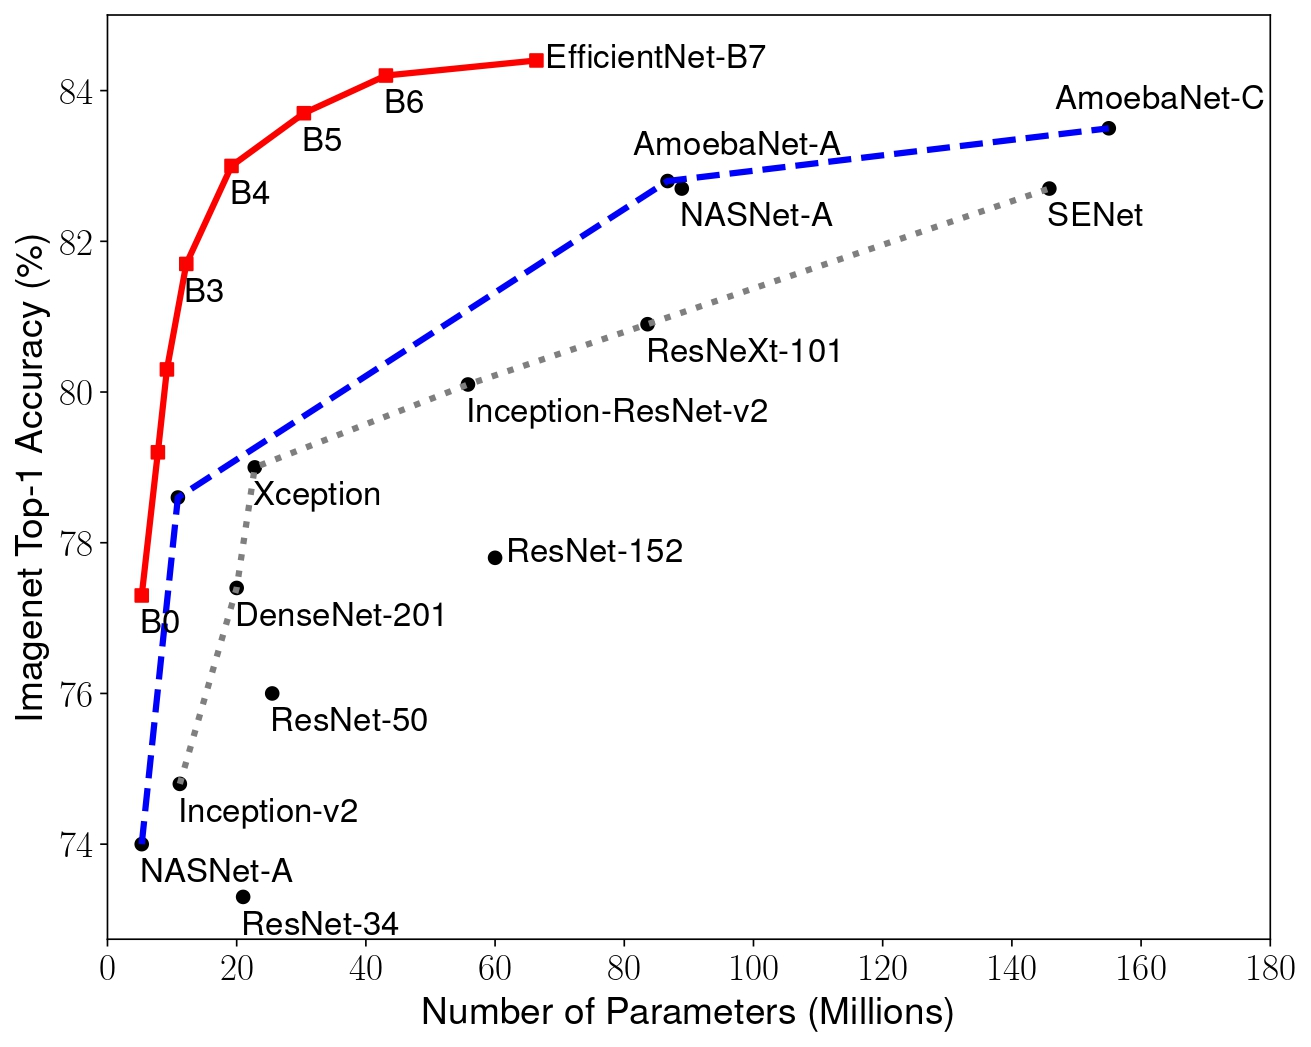

[Источник](https://github.com/isadrtdinov/intro-to-dl-hse/blob/1fd3f9bf82fc7aa8e0475210318423559f02f582/lecture-notes/notes-05-cnn.pdf)

### Не свёрточные модели

Текущая State-of-the-art (SOTA) в классификации изображений принадлежит трансформерам, но об этом мы поговорим в следующих лекциях. Не смотря, на проигрыш в качестве лучшей модели, свёрточные сети все еще очень популярны.

Основные **преимущества** свёрточных архитектур:

- Быстрее и проще учатся

- Более эффективные по вычислениям

- Хорошо работают на малых данных

Например, если вам нужно запустить модель компьютерного зрения на весах в продуктовом магазине, то что-то сложнее свёрточной сети будет дорого и сложно запустить в real-time.

Кроме того, свёрточные сети можно использовать для обработки аудио или иных числовых последовательностей. Также есть подходы и идеи, как сделать использовать идеи из трансформеров в свёрточных архитектурах, например ConvNet [Liu et al., 2022](https://arxiv.org/abs/2201.03545), примерно 12 тысяч цитирований.


Отметим, что идеи и знания, которые получили люди при решении задачи классификации изображений часто переносят и на текущие работы. Например, почти все современные архитектуры используют **skip connections**, а также встречаются методы не использующие **end-to-end** обучение.

### Судьба ImageNet

К сожалению, со временем стало появляться все больше инженерных работ, в которых отсуствовали новые и интересные идеи. Люди стали гнаться за сотыми процентов и плодить кучу разных архитектур разной степени красивости. Ниже представлены основные результаты в области.

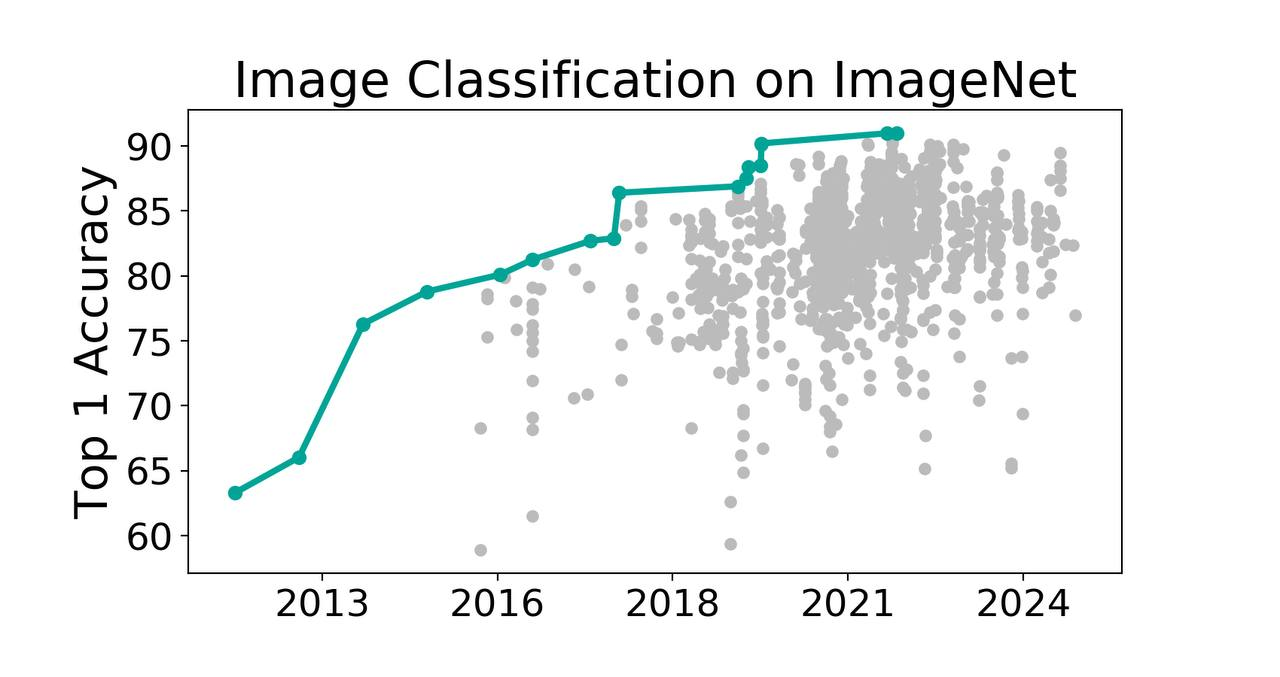

## Transfer learning

Весь рассказ выше строился вокруг датасета `ImageNet` в котором более миллиона изображений. Часто не бывает в наличии настолько большой обучающей выборки, а обучать большие модели на маленьком объеме данных очень трудно и приводит к переобучению.

Для решения этой задачи существует подход `transfer learning`. Мы будем использовать уже предобученные модели в качестве при решении своей конкретной задачи (например, классификация листьев деревьев).

### Pre-training (предобучение)

Для начала обучим модель на какой-то общей задаче (большом объеме данных, например, `ImageNet`). Мы предполагаем, что модель научилась извлекать признаки, которые хорошо обобщаются на схожие данные (например, на `Cifar10`). Так как модель не переобучилась и показывает хорошее качество на тесте, у нас есть надежда на обобщающую способность.

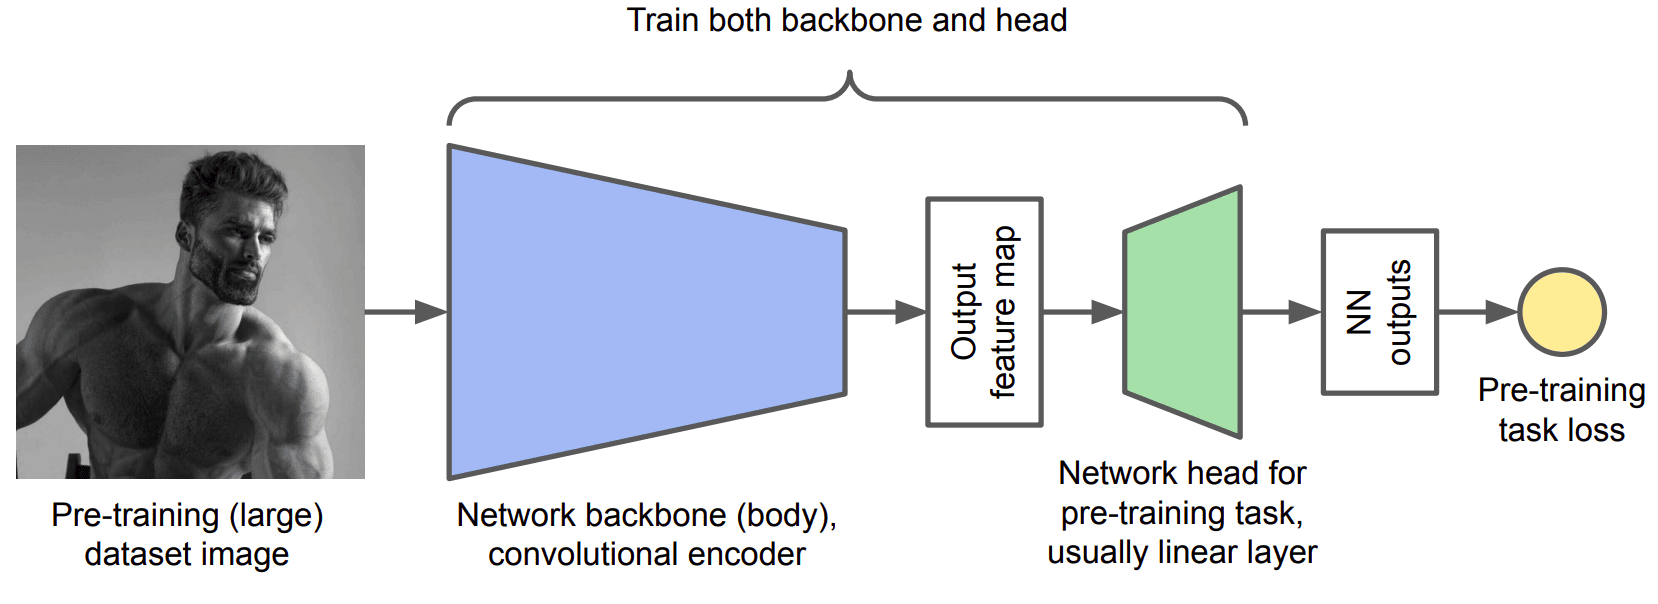

[Источник](https://github.com/isadrtdinov/intro-to-dl-hse/blob/1fd3f9bf82fc7aa8e0475210318423559f02f582/lecture-notes/notes-05-cnn.pdf)

### Linear probing

Далее возьмем предобученную модель и заморозим все веса. Мы уже знаем, что модель извлекла хорошие признаки, значит на них мы можем обучить MLP/линейный слой. Для этого мы заменим в модели линейный слой (так как число классов скорее всего поменялось), заморозим все остальные веса и будем обучать модель.




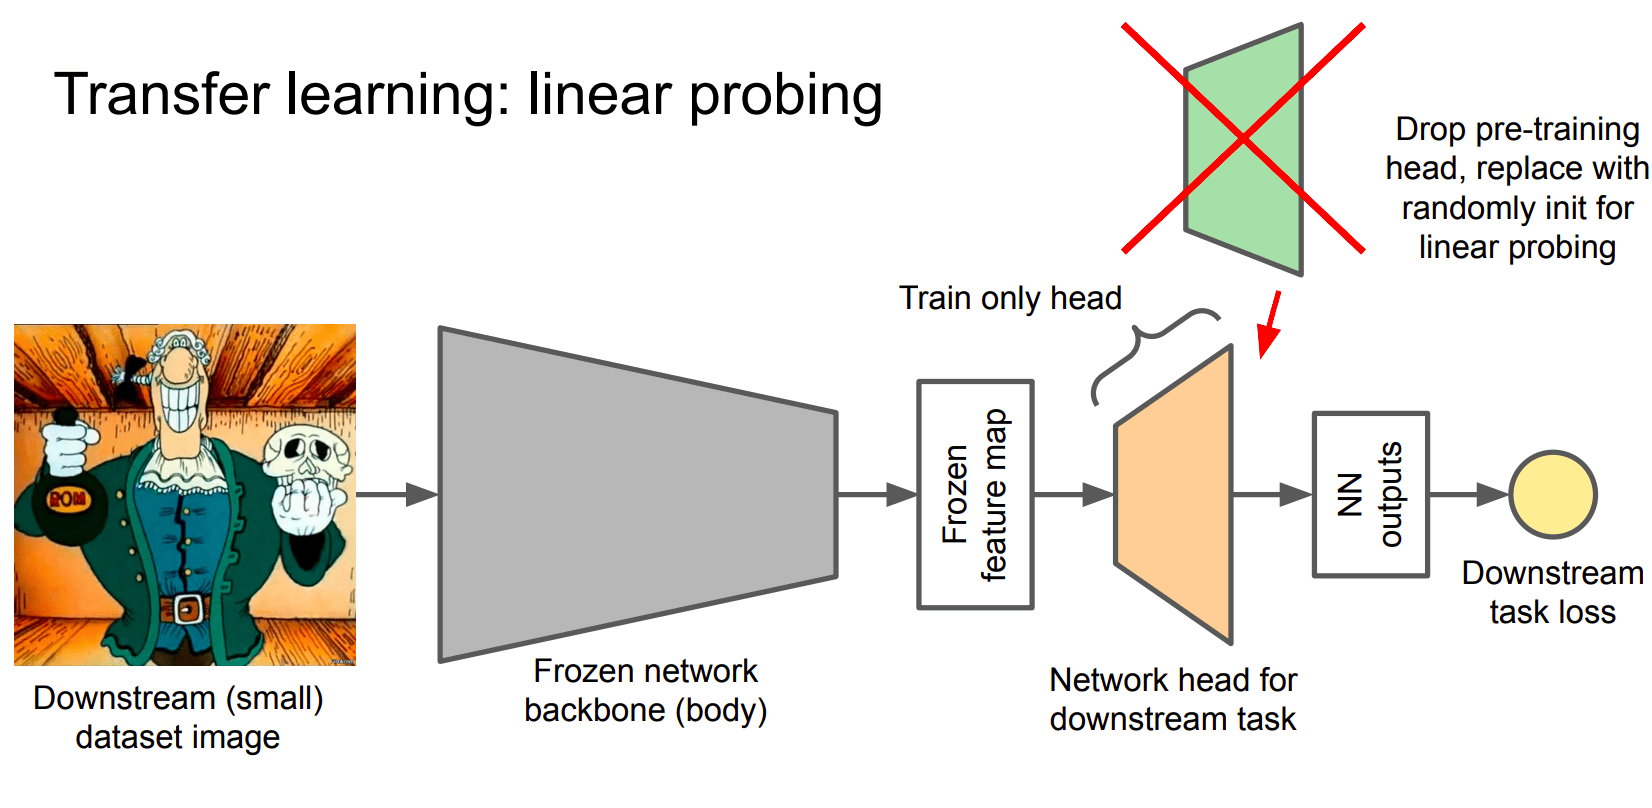

[Источник](https://github.com/isadrtdinov/intro-to-dl-hse/blob/1fd3f9bf82fc7aa8e0475210318423559f02f582/lecture-notes/notes-05-cnn.pdf)

### Finetuning

Мы также заменяем голову модели (линейный слой) с целью предсказания нужного числа классов, но будем обучать всю модель целиком. Идейно мы обучаемся не со случайной инициализации весов, а в окрестности какого-то "достаточно хорошего" минимума. Есть отдельные работы по исследованию минимумов и как именно нужно обучать модель в таком режиме.

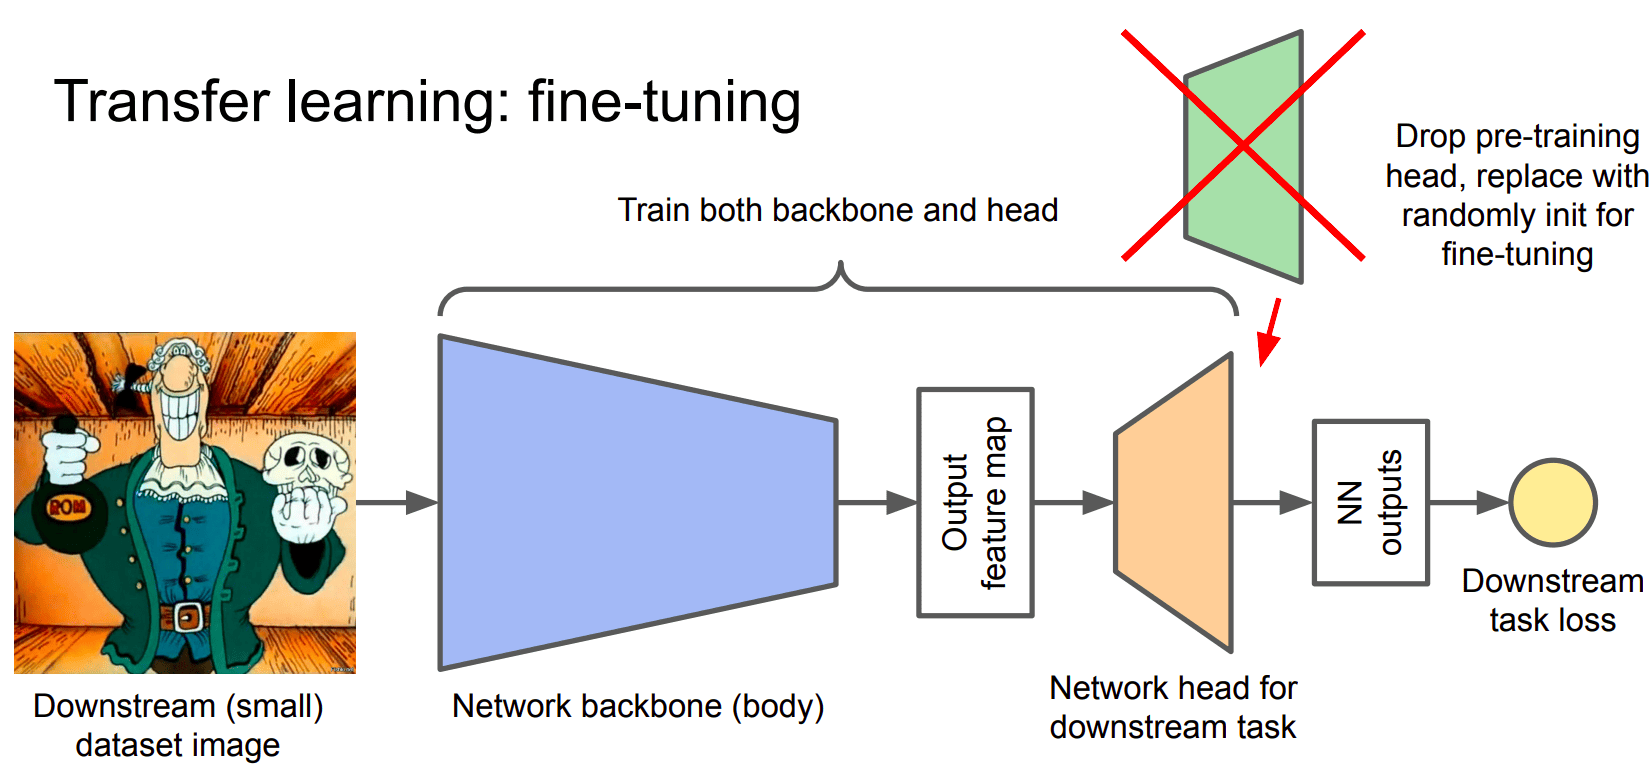

[Источник](https://github.com/isadrtdinov/intro-to-dl-hse/blob/1fd3f9bf82fc7aa8e0475210318423559f02f582/lecture-notes/notes-05-cnn.pdf)

Рассмотренные подходы можно комбинировать, например заморозить только первые слои, а обучать остальные и тому подобное.

<font color='orange'>**Вопрос:**</font> В каком режиме обучения модель больше подвержена переобучению?
    
<font color='orange'>**Вопрос:**</font> В каком режиме можно найти более хорошее решение задачи, то есть выбить выше качество?

#### Ответ:

Чем больше степеней свободы и параметров, тем вероятней переобучение, но тем выше итоговое качество. Значит linear probing меньше подвержен переобучению, но обычно сходится к более низкому качеству, чем fine-tuning, который вероятней может переобучится (особенно если выборка маленькая).

<font color='orange'>**Вопрос:**</font> Можно ли взять приемущества и fine-tuning и linear probing? Какие есть промежуточные решения?

#### Ответ:

Например, можно разморозить последние $N$ слоев. Размораживать первые слои не имеет смысла, так как последующие ожидают на вход другие признаки.

В будущем мы рассмотрим методы эффективного fine-tuning (Parameter-Efficient Fine-Tuning/PEFT). 

## Заключение


- Модели, которые используют знания о данных (`Inductive bias`) работают лучше
- Наличие и создание единых бэнчмарков позволяет области развиваться
- Методы и подходы из компьютерного зрения переиспользовались в других областях и наоборот
- Решение сложных задач на больших датасетах позволяет получать хорошие результаты и на маленьких выборках